# Python Lesson 51: Birthday Problem

**Concept page:** `wiki/concepts/birthday-problem.md` · **Area:** probability

**You will be able to:**
- compute analytic probabilities with the complement trick
- verify by simulation
- find the n that reaches probability 0.5

*How to use:* run the cells top to bottom, read the output, then try the **Exercises** in the empty cells before opening the **Solutions** section at the bottom.

In [1]:
import numpy as np
import sympy as sp
import matplotlib
import matplotlib.pyplot as plt
np.set_printoptions(precision=4, suppress=True)
%matplotlib inline

## 1. Match a given date

In [2]:
def p_given(n): return 1-(364/365)**n
n=1
while p_given(n)<0.5: n+=1
print(n, p_given(n))      # 253

253 0.5004771540365807


## 2. Any two share a birthday

In [3]:
def p_any(n): return 1-np.prod((365-np.arange(n))/365)
n=1
while p_any(n)<0.5: n+=1
print(n, p_any(n), p_any(57))      # 23, ~0.507, ~0.99

23 0.5072972343239857 0.9901224593411699


## 3. Simulation

In [4]:
rng=np.random.default_rng(0)
def sim_any(n,trials=20000):
    b=rng.integers(0,365,size=(trials,n)); return np.mean([len(set(r))<n for r in b])
def sim_given(n,trials=20000): return np.mean((rng.integers(0,365,size=(trials,n))==0).any(axis=1))
print(sim_any(23),p_any(23)); print(sim_given(253),p_given(253))

0.49815 0.5072972343239857
0.4967 0.5004771540365807


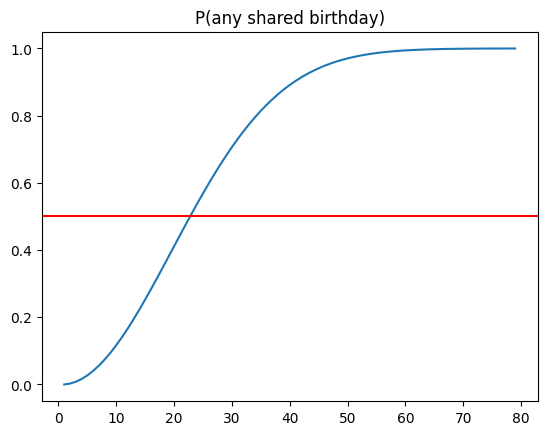

In [5]:
ns=np.arange(1,80); plt.plot(ns,[p_any(k) for k in ns]); plt.axhline(.5,c='r'); plt.title("P(any shared birthday)"); plt.show()

## Cambodian textbook corner (កម្មវិធីសិក្សាកម្ពុជា)
Grade 9 lesson 8: P = favourable/possible cases; the complement trick counts the unfavourable cases instead.

In [6]:
print(1-364/365)

0.002739726027397249


## Exercises

**Exercise 1.** Probability nobody in a class of 30 is born in January (assume 1/12 per month): (11/12)^30 = 0.0735.

In [7]:
# your code here

**Exercise 2.** How many people are needed so that P(at least one born on a given day) >= 0.9?

In [8]:
# your code here

## Solutions
*(Try the exercises first!)*

In [9]:
# Solution 1
p=(11/12)**30; print(p); assert abs(p-0.0735)<1e-3

0.0735094499934193


In [10]:
# Solution 2
n=1
while p_given(n)<0.9: n+=1
print(n); assert n==840

840
